# 030 损失曲面与优化问题

## Goal
从数据重新计算曲面、等高线和梯度场，用独立闭式解检查结果。五点最优为(3/5,6/5)，J*=4/25。明确区分有限步算法状态与模型有效性。所有数据是确定性合成教学例，无真实任务效果含义。

## Setup
从本讲目录打开，选择正确Python内核，重启并顺序执行。依赖见environment.yml和requirements.txt。实际制作验证使用新Python进程中的真实InProcessKernel；Anaconda安装、浏览器Jupyter界面和外部进程传输未测试。

In [1]:
from pathlib import Path
import io
import json
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display
import experiment as e
ROOT = Path.cwd()
if not (ROOT / 'data/cases.csv').exists():
    raise FileNotFoundError('Open this notebook from the unit directory')
plt.rcParams.update({'figure.dpi':110, 'font.size':10, 'axes.spines.top':False, 'axes.spines.right':False})
def show_figure(fig):
    fig.tight_layout()
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=130, bbox_inches='tight')
    plt.close(fig)
    display(Image(data=buf.getvalue(), format='png'))


## Steps
### 1 先验证全部输入
本Notebook用完整文件SHA256锁定默认输入，以保护后面纸笔公式和数值参照。改变输入请用脚本或另存并同步修改Notebook推导。焦点未选中的场景、最后一个候选和路径同样需要验证。compile_report在开始求解前再次检查完整配置与数据；不要先挑一组合法输入就绕过其他字段。

In [2]:
import hashlib
BASELINE_HASHES = {'data/cases.csv': '4609bae2ecc4274331a508e5134082b8f4498e8a4b2a9f13129baf191d2e01f6', 'data/model_spec.json': 'a8dfc0f2702252f3a539d7dfc305b67acf99b1607e6e1d4b3c6d5399c95c6e9b'}
for relative, expected in BASELINE_HASHES.items():
    if hashlib.sha256((ROOT / relative).read_bytes()).hexdigest() != expected:
        raise ValueError('This notebook uses packaged baseline formulas. Restore both baseline inputs; use experiment.py for changed inputs.')
groups = e.read_cases(ROOT / 'data/cases.csv')
cfg = e.read_config(ROOT / 'data/model_spec.json')
report = e.compile_report(groups, cfg)
x = np.array(groups['hand']['x'])
y = np.array(groups['hand']['y'])
ref = report['geometry']['hand']['reference']
print('NumPy', np.__version__)
print('Rows:', {k: len(v['x']) for k,v in groups.items()})
print('Independent exact reference:', ref['exact_theta'], ref['exact_minimum_loss'])
print('Shapes:', x.shape, y.shape)


NumPy 2.3.5
Rows: {'hand': 5, 'constant': 3, 'changed_sample': 5}
Independent exact reference: ['3/5', '6/5'] 4/25
Shapes: (5,) (5,)


### 2 一点参数对应一条线
(1,1)的残差为预测减观测；对照手算J=0.2及梯度(0,-0.4)。最优训练损失仍不为0。

{'theta': [1.0, 1.0], 'loss': 0.2, 'gradient': [0.0, -0.4], 'gradient_norm': 0.4}


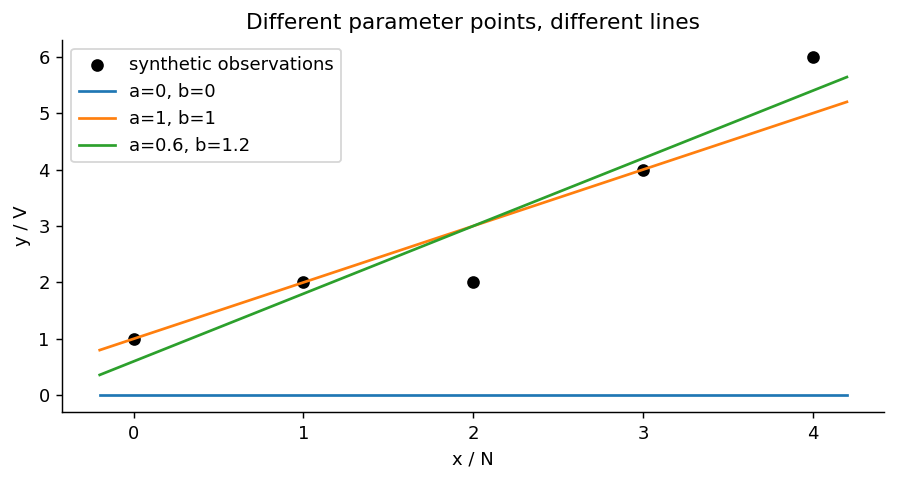

In [3]:
print(e.loss_gradient(x,y,[1,1]))
fig,ax=plt.subplots(figsize=(7,3.8))
t=np.linspace(-.2,4.2,100)
ax.scatter(x,y,color='black',label='synthetic observations')
for a,b in [(0,0),(1,1),(.6,1.2)]:
    ax.plot(t,a+b*t,label=f'a={a}, b={b}')
ax.set(xlabel='x / N',ylabel='y / V',title='Different parameter points, different lines')
ax.legend();show_figure(fig)


### 3 曲面与等高线
网格xy约定使行改变b、列改变a。真最优来自数据闭式解，不能用网格最低点替代。

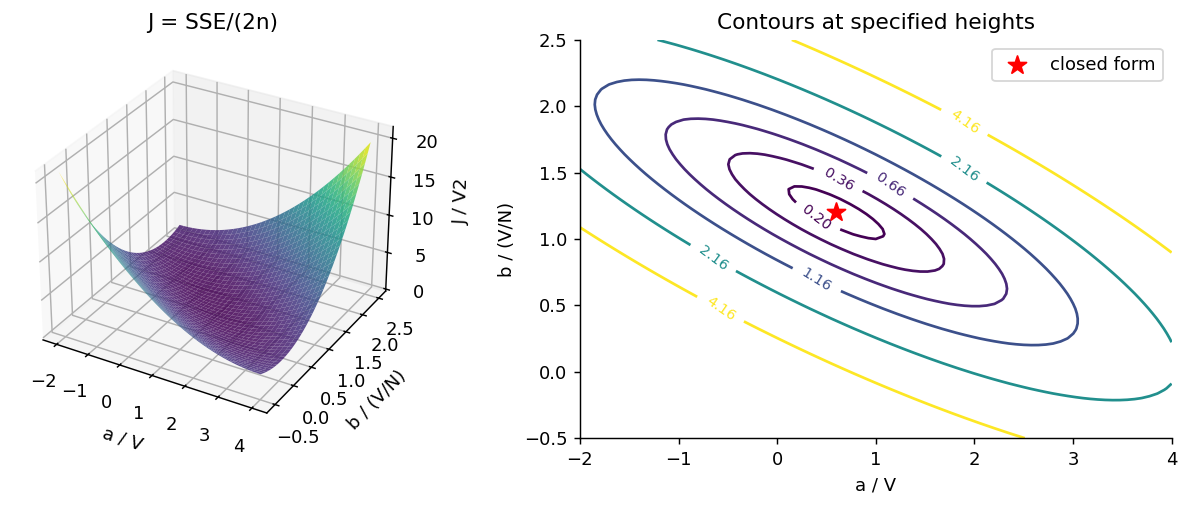

Grid minimum: {'shape': [81, 81], 'minimum_sampled_loss': 0.16015625, 'minimum_sampled_theta': [0.625, 1.1875], 'note': 'finite grid minimum is not a proof of continuous global optimality'}


In [4]:
A,B,Z=e.surface(x,y,cfg['grid'])
if not (A.shape == B.shape == Z.shape == (81,81)):
    raise RuntimeError('Unexpected grid shape')
if not np.isclose(Z[0,0],e.loss_gradient(x,y,[A[0,0],B[0,0]])['loss']):
    raise RuntimeError('Grid orientation mismatch')
fig=plt.figure(figsize=(10,4))
ax=fig.add_subplot(121,projection='3d')
ax.plot_surface(A,B,Z,cmap='viridis',alpha=.85)
ax.set(xlabel='a / V',ylabel='b / (V/N)',zlabel='J / V2',title='J = SSE/(2n)')
ax=fig.add_subplot(122)
c=ax.contour(A,B,Z,levels=[.2,.36,.66,1.16,2.16,4.16])
ax.clabel(c,fontsize=8)
ax.scatter(*ref['theta'],c='red',marker='*',s=110,label='closed form')
ax.set(xlabel='a / V',ylabel='b / (V/N)',title='Contours at specified heights')
ax.legend();show_figure(fig)
print('Grid minimum:',report['grid'])


### 4 方向场
箭头已归一化，只表示负梯度方向。近零梯度显式掩蔽，避免0除0。等比例坐标用于比较夹角。

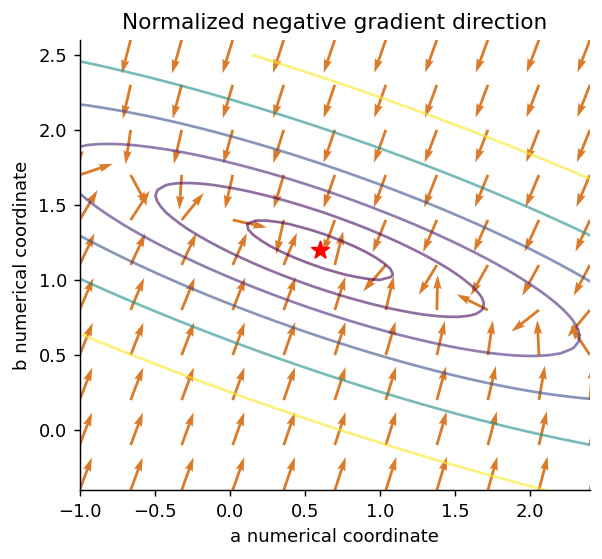

In [5]:
ag,bg=np.meshgrid(np.linspace(-1,2.4,11),np.linspace(-.4,2.6,11),indexing='xy')
ga=ag+2*bg-3;gb=2*ag+6*bg-8.4
gn=np.hypot(ga,gb)
u=np.divide(-ga,gn,out=np.zeros_like(ga),where=gn>1e-12)
v=np.divide(-gb,gn,out=np.zeros_like(gb),where=gn>1e-12)
fig,ax=plt.subplots(figsize=(6.5,4.4))
ax.contour(A,B,Z,levels=[.2,.36,.66,1.16,2.16,4.16],alpha=.6)
ax.quiver(ag,bg,u,v,angles='xy',scale_units='xy',scale=4.3,color='#db7b29')
ax.scatter(.6,1.2,c='red',marker='*',s=100)
ax.set(xlim=(-1,2.4),ylim=(-.4,2.6),xlabel='a numerical coordinate',ylabel='b numerical coordinate',title='Normalized negative gradient direction')
ax.set_aspect('equal');show_figure(fig)


### 5 梯度的独立检查
中心差分用于定位实现错误；另外保留纸笔梯度锚点以防两段程序共享同一错误。二次函数在精确算术下中心差分无截断误差，极小步幅仍会引起舍入。

In [6]:
theta=np.array([1.,1.]);target=np.array([0.,-.4])
rows=[]
for h in [1e-3,1e-5,1e-7]:
    fd=[]
    for j in range(2):
        d=np.zeros(2);d[j]=h
        fd.append((e.loss_gradient(x,y,theta+d)['loss']-e.loss_gradient(x,y,theta-d)['loss'])/(2*h))
    rows.append({'h':h,'difference':fd,'max_error':float(np.max(np.abs(np.array(fd)-target)))})
print(json.dumps(rows,indent=2))
if not np.allclose(e.loss_gradient(x,y,theta)['gradient'],target,rtol=0,atol=1e-14):
    raise RuntimeError('Paper gradient anchor failed')


[
  {
    "h": 0.001,
    "difference": [
      0.0,
      -0.3999999999999976
    ],
    "max_error": 2.4424906541753444e-15
  },
  {
    "h": 1e-05,
    "difference": [
      0.0,
      -0.3999999999990122
    ],
    "max_error": 9.87820936160233e-13
  },
  {
    "h": 1e-07,
    "difference": [
      1.3877787807814457e-10,
      -0.4000000000670134
    ],
    "max_error": 1.3877787807814457e-10
  }
]


### 6 曲率与坐标
对称Hessian的特征值应与(7±sqrt(41))/2一致。均值坐标m=a+2b下交叉项消失，但梯度更新的坐标度量也改变。

Hessian: [[1.0, 2.0], [2.0, 6.0]] eigenvalues: [0.2984378812835756, 6.701562118716424]


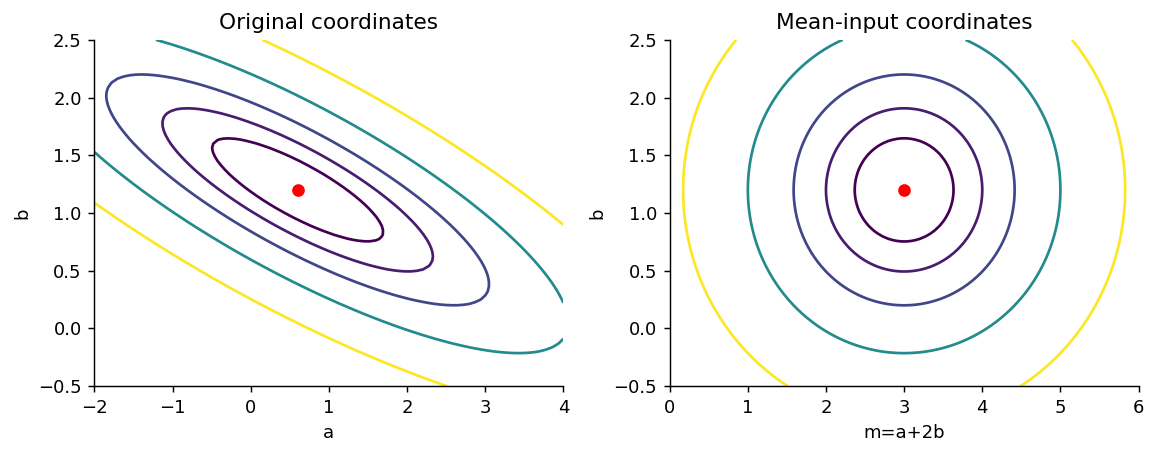

In [7]:
H=np.array(report['geometry']['hand']['hessian'])
eigenvalues=np.linalg.eigvalsh(H)
expected=np.array([(7-np.sqrt(41))/2,(7+np.sqrt(41))/2])
if not np.allclose(eigenvalues,expected,rtol=1e-14,atol=1e-14):
    raise RuntimeError('Hessian spectrum failed')
print('Hessian:',H.tolist(),'eigenvalues:',eigenvalues.tolist())
M,SB=np.meshgrid(np.linspace(0,6,100),np.linspace(-.5,2.5,100))
SZ=.16+.5*(M-3)**2+(SB-1.2)**2
fig,axs=plt.subplots(1,2,figsize=(9,3.6))
axs[0].contour(A,B,Z,levels=[.36,.66,1.16,2.16,4.16])
axs[1].contour(M,SB,SZ,levels=[.36,.66,1.16,2.16,4.16])
axs[0].scatter(.6,1.2,c='red');axs[1].scatter(3,1.2,c='red')
axs[0].set(xlabel='a',ylabel='b',title='Original coordinates')
axs[1].set(xlabel='m=a+2b',ylabel='b',title='Mean-input coordinates')
show_figure(fig)


### 7 有限预算轨迹
下面实际计算三条路径。预算耗尽和增长保护都不是成功。quadratic_gap来自非负二次式，避免接近最优时两项相减抵消；它仍使用浮点参照坐标。

t= 0 theta= 0 0
columns: x, prediction, residual, squared residual, gradient-a contribution, gradient-b contribution
0 | 0 | -1 | 1 | -1/5 | 0
1 | 0 | -2 | 4 | -2/5 | -2/5
2 | 0 | -2 | 4 | -2/5 | -4/5
3 | 0 | -4 | 16 | -4/5 | -12/5
4 | 0 | -6 | 36 | -6/5 | -24/5
J= 61/10 gradient= ('-3', '-42/5')
next parameters= ('3/5', '42/25')
t= 1 theta= 3/5 42/25
columns: x, prediction, residual, squared residual, gradient-a contribution, gradient-b contribution
0 | 3/5 | -2/5 | 4/25 | -2/25 | 0
1 | 57/25 | 7/25 | 49/625 | 7/125 | 7/125
2 | 99/25 | 49/25 | 2401/625 | 49/125 | 98/125
3 | 141/25 | 41/25 | 1681/625 | 41/125 | 123/125
4 | 183/25 | 33/25 | 1089/625 | 33/125 | 132/125
J= 532/625 gradient= ('24/25', '72/25')
next parameters= ('51/125', '138/125')
t= 2 theta= 51/125 138/125
columns: x, prediction, residual, squared residual, gradient-a contribution, gradient-b contribution
0 | 51/125 | -74/125 | 5476/15625 | -74/625 | 0
1 | 189/125 | -61/125 | 3721/15625 | -61/625 | -61/625
2 | 327/125 | 

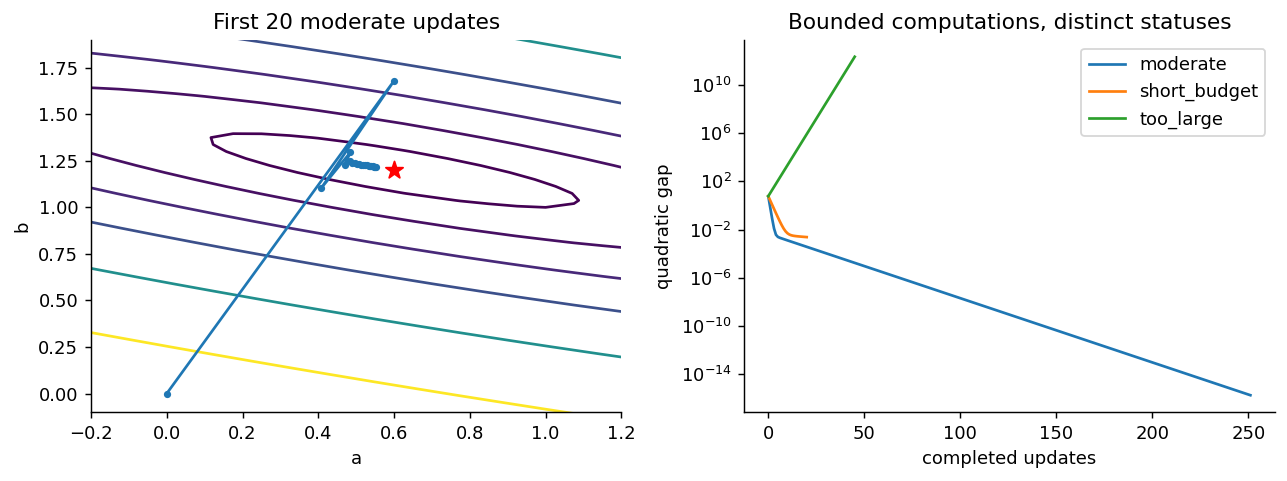

In [8]:
# Recompute every row at all three states using independent rational arithmetic.
from fractions import Fraction
F = Fraction
paper_theta = [(F(0), F(0)), (F(3,5), F(42,25)), (F(51,125), F(138,125))]
for paper_t, (pa, pb) in enumerate(paper_theta):
    paper_rows = []
    for px, py in zip(x, y):
        fx, fy = F.from_float(float(px)), F.from_float(float(py))
        prediction = pa + pb * fx
        residual = prediction - fy
        paper_rows.append((fx, prediction, residual, residual**2, residual/5, fx*residual/5))
    print('t=', paper_t, 'theta=', str(pa), str(pb))
    print('columns: x, prediction, residual, squared residual, gradient-a contribution, gradient-b contribution')
    for values in paper_rows:
        print(' | '.join(map(str, values)))
    paper_loss = sum(row[3] for row in paper_rows) / 10
    paper_gradient = (sum(row[4] for row in paper_rows), sum(row[5] for row in paper_rows))
    print('J=', str(paper_loss), 'gradient=', tuple(map(str, paper_gradient)))
    actual = e.loss_gradient(x, y, [float(pa), float(pb)])
    if not np.isclose(actual['loss'], float(paper_loss)) or not np.allclose(actual['gradient'], list(map(float,paper_gradient))):
        raise RuntimeError('Row-wise forward/gradient reference mismatch')
    if paper_t < 2:
        updated = (pa-F(1,5)*paper_gradient[0], pb-F(1,5)*paper_gradient[1])
        if updated != paper_theta[paper_t+1]:
            raise RuntimeError('Paper update mismatch')
        print('next parameters=', tuple(map(str, updated)))

for p in report['paths']:
    print(p['name'],p['status'],'updates=',p['updates_completed'],'J=',p['final']['loss'],'gradient norm=',p['final']['gradient_norm'])
first=report['paths'][0]['history']
if not np.allclose([first[1]['theta'],first[2]['theta']],[[.6,1.68],[.408,1.104]],rtol=0,atol=2e-14):
    raise RuntimeError('Paper two-step anchor failed')
fig,axs=plt.subplots(1,2,figsize=(10,3.8))
axs[0].contour(A,B,Z,levels=[.2,.36,.66,1.16,2.16,4.16])
p=np.array([r['theta'] for r in first[:21]])
axs[0].plot(p[:,0],p[:,1],'o-',markersize=3)
axs[0].scatter(.6,1.2,c='red',marker='*',s=100)
axs[0].set(xlim=(-.2,1.2),ylim=(-.1,1.9),xlabel='a',ylabel='b',title='First 20 moderate updates')
for path in report['paths']:
    axs[1].semilogy([r['iteration'] for r in path['history']],[r['quadratic_gap'] for r in path['history']],label=path['name'])
axs[1].set(xlabel='completed updates',ylabel='quadratic gap',title='Bounded computations, distinct statuses')
axs[1].legend();show_figure(fig)


### 8 平谷中的不同参数
constant的闭式代表为(7/3,0)，只是无穷多个最优解之一；训练位置以外预测不唯一。

{'theta': [2.3333333333333335, 0.0], 'minimum_loss': 0.7777777777777778, 'exact_theta': ['7/3', '0'], 'exact_minimum_loss': '7/9', 'x_mean': 2.0, 'y_mean': 2.3333333333333335, 'Sxx': 0.0, 'unique_parameters': False, 'meaning': 'exact rational reference for stored binary64 data; decimal output rounded'}


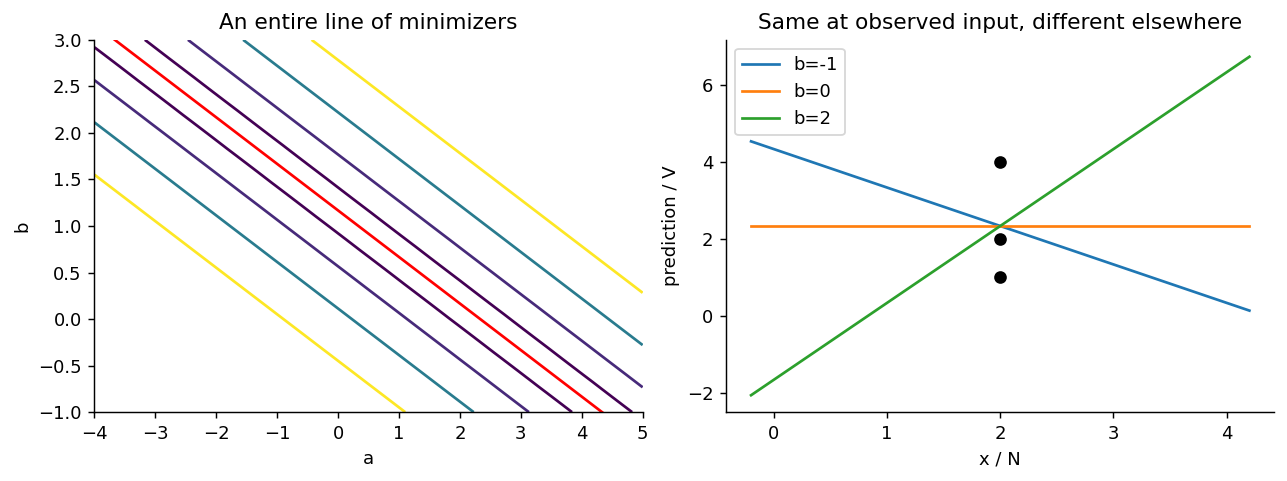

In [9]:
flat=report['geometry']['constant']['reference']
print(flat)
FA,FB=np.meshgrid(np.linspace(-4,5,100),np.linspace(-1,3,100))
FZ=7/9+.5*(FA+2*FB-7/3)**2
fig,axs=plt.subplots(1,2,figsize=(10,3.8))
axs[0].contour(FA,FB,FZ,levels=[.9,1.5,3,6])
slopes=np.linspace(-1,3,50);axs[0].plot(7/3-2*slopes,slopes,color='red')
axs[0].set(xlabel='a',ylabel='b',title='An entire line of minimizers')
for b in [-1,0,2]:axs[1].plot(t,7/3+b*(t-2),label=f'b={b}')
axs[1].scatter([2,2,2],[1,2,4],color='black');axs[1].legend()
axs[1].set(xlabel='x / N',ylabel='prediction / V',title='Same at observed input, different elsewhere')
show_figure(fig)


### 9 边界最优
b≤1改变可行域。正确解(1,1)需要重新调整截距，简单裁剪原解的斜率得到(0.6,1)并不最优。

Constrained: {'theta': [1.0, 1.0], 'loss': 0.2, 'gradient': [0.0, -0.4], 'gradient_norm': 0.4, 'exact_theta': ['1', '1'], 'exact_loss': '1/5', 'constraint': 'slope <= upper', 'slope_upper': 1.0}
Clipped only: 0.27999999999999997


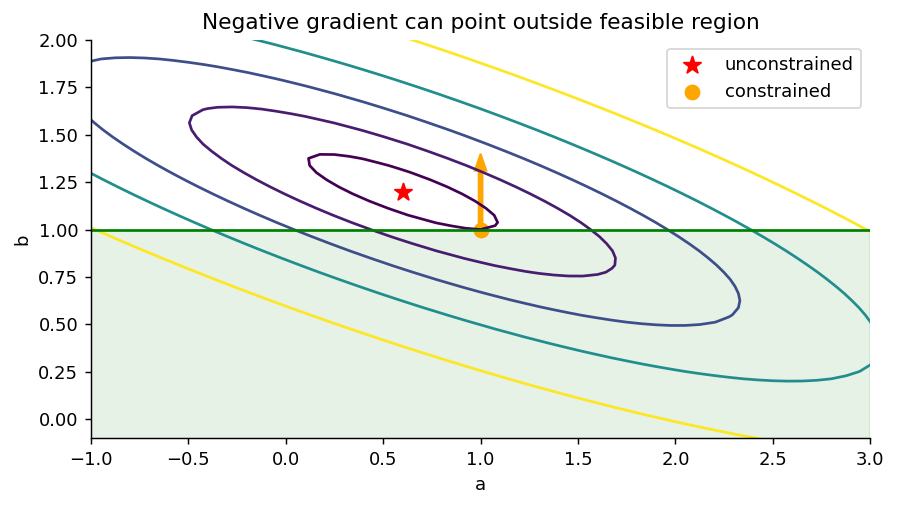

In [10]:
con=e.constrained_reference(x,y,1)
print('Constrained:',con)
print('Clipped only:',e.loss_gradient(x,y,[.6,1])['loss'])
fig,ax=plt.subplots(figsize=(7,4))
ax.contour(A,B,Z,levels=[.2,.36,.66,1.16,2.16])
ax.axhspan(-.5,1,color='green',alpha=.1);ax.axhline(1,color='green')
ax.scatter(.6,1.2,c='red',marker='*',s=100,label='unconstrained')
ax.scatter(1,1,c='orange',s=60,label='constrained')
ax.arrow(1,1,0,.4,width=.02,color='orange',length_includes_head=True)
ax.set(xlim=(-1,3),ylim=(-.1,2),xlabel='a',ylabel='b',title='Negative gradient can point outside feasible region')
ax.legend();show_figure(fig)


### 10 不同风险地图
以下总体被显式指定，不是根据训练拟合结果反推：X均匀取0..4，Y=1+X+ε，条件噪声均值0、方差1/4。样本最优的总体风险可能高于总体最优。

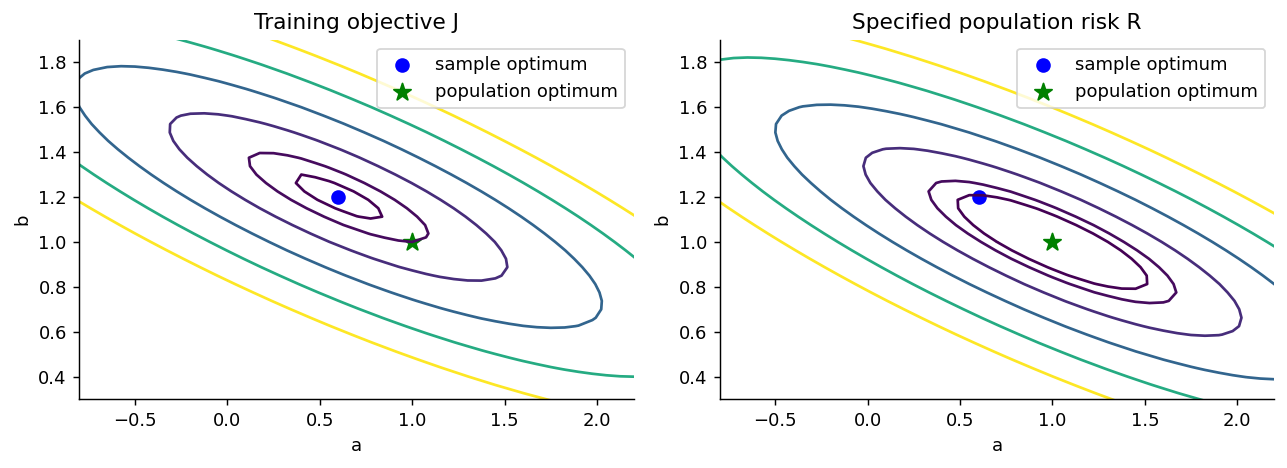

[1, 1] training= 0.2 population= 0.125
[0.6, 1.2] training= 0.15999999999999998 population= 0.16499999999999998
Changed sample exact optimum: ['4/5', '13/10']


In [11]:
risk=.125+.5*(A-1+2*(B-1))**2+(B-1)**2
fig,axs=plt.subplots(1,2,figsize=(10,3.7))
for ax,z,title in zip(axs,[Z,risk],['Training objective J','Specified population risk R']):
    ax.contour(A,B,z,levels=[.17,.2,.3,.5,.8,1.2])
    ax.scatter(.6,1.2,c='blue',s=50,label='sample optimum')
    ax.scatter(1,1,c='green',marker='*',s=100,label='population optimum')
    ax.set(xlim=(-.8,2.2),ylim=(.3,1.9),xlabel='a',ylabel='b',title=title)
    ax.legend()
show_figure(fig)
for theta in [[1,1],[.6,1.2]]:
    population=.125+np.mean(((theta[0]-1)+(theta[1]-1)*x)**2)/2
    print(theta,'training=',e.loss_gradient(x,y,theta)['loss'],'population=',population)
print('Changed sample exact optimum:',report['geometry']['changed_sample']['reference']['exact_theta'])


## Checks
### 11 全配置守卫和失败完整性
故意制造末字段非法、重复键和未选中末行非法。每项必须明确拒绝；旧报告不能被清空，新报告和目录不能提前创建。这些是教学用例，不是完整生产安全审计。

In [12]:
import copy
import tempfile
bad=copy.deepcopy(cfg);bad['candidate_parameters'][-1][-1]=True
try:e.compile_report(groups,bad)
except ValueError as exc:print('Rejected final candidate:',str(exc))
else:raise RuntimeError('Invalid last candidate was accepted')
with tempfile.TemporaryDirectory() as directory:
    temp=Path(directory)
    badcsv=temp/'bad.csv'
    badcsv.write_text((ROOT/'data/cases.csv').read_text().replace('changed_sample,S05,4,6','changed_sample,S05,4,1e-400'))
    old=temp/'old.json';old.write_bytes(b'SENTINEL')
    for destination in [old,temp/'new'/'report.json']:
        try:e.run(badcsv,ROOT/'data/model_spec.json',destination)
        except ValueError:pass
        else:raise RuntimeError('Malformed final CSV row was accepted')
    if old.read_bytes()!=b'SENTINEL' or (temp/'new').exists():
        raise RuntimeError('Failure modified output')
    duplicate=temp/'duplicate.json'
    duplicate.write_text('{"slope_upper":1,"slope_upper":0}')
    try:e.read_config(duplicate)
    except ValueError as exc:print('Rejected duplicate key:',str(exc))
    else:raise RuntimeError('Duplicate key accepted')
print('True zero token accepted:',e.number_token('0e-400'))
print('Failure integrity checks passed')


Rejected final candidate: candidate[1] requires an ordinary real scalar
Rejected duplicate key: duplicate JSON key: slope_upper
True zero token accepted: 0.0
Failure integrity checks passed


### 12 零预算也要检查当前状态
预算为0意味着不更新，不意味着不评估。先检查当前梯度，再判断预算耗尽；所有参数必须先合法。

In [13]:
base={'name':'zero_budget','initial':[0,0],'step':.2,'max_steps':0,'gradient_tolerance':1e-8}
far=e.trace_path(x,y,base)
near=e.trace_path(x,y,{**base,'initial':[.6,1.2]})
print('Nonoptimal initial:',far['status'],far['updates_completed'])
print('Optimal initial:',near['status'],near['updates_completed'])
if far['status']!='budget_exhausted' or near['status']!='gradient_tolerance_met':
    raise RuntimeError('Zero-budget status semantics failed')


Nonoptimal initial: budget_exhausted 0
Optimal initial: gradient_tolerance_met 0


## Next Steps
本次默认执行：moderate在251步满足梯度阈值，短预算20步停止，过大步长在45步后因下一候选超过保护范围而停止。五点闭式最小值4/25；常数输入有无穷多个最优参数；b≤1下最优梯度不为零；训练与总体两张地图的最低点不同。

这些是有限binary64教学验证，不是现实预测质量或CPU性能结论。继续第031讲学习一维步长区间，再于第032讲学习多维谱与尺度。软件API来源见source-checks.json，完整数学论证见lecture.pdf，16题解答见answers.pdf。